In [1]:
import os
from skimage.metrics import structural_similarity
from skimage.metrics import mean_squared_error
import math
import numpy as np
import sirf.Gadgetron as pMR
import matplotlib.pyplot as plt


data_path = '/home/jovyan/devel/SIRF-Contribs/src/notebooks/'
os.chdir(data_path)
import utils
from utils import plot_rpe_3d, plot_rpe_3d_simple

# Can use either of these two as ground truth
ground_truth_with_TV = np.load(os.path.join(data_path, 'ground_truth_with_TV.npy'))
ground_truth_no_TV = np.load(os.path.join(data_path, 'ground_truth_no_TV.npy'))

Nms = 60


def rmse(input_im, ground_truth, border=20):
    if np.shape(input_im)!=np.shape(ground_truth):
        raise ValueError('imgs have diff shape')
    mse = mean_squared_error(np.abs(input_im[border:-border,border:-border,border:-border]), \
        np.abs(ground_truth[border:-border,border:-border,border:-border]))
    return math.sqrt(mse)

def nrmse(input_im, ground_truth, border=20):
    if np.shape(input_im)!=np.shape(ground_truth):
        raise ValueError('imgs have diff shape')
    mse = mean_squared_error(np.abs(input_im[border:-border,border:-border,border:-border]), \
        np.abs(ground_truth[border:-border,border:-border,border:-border]))
    return math.sqrt(mse) / np.max(np.abs(ground_truth))

def ssim(input_im, ground_truth, border=20):
    if np.shape(input_im)!=np.shape(ground_truth):
        raise ValueError('imgs have diff shape')
    res_ssim = structural_similarity(np.abs(input_im[border:-border,border:-border,border:-border]), \
        np.abs(ground_truth[border:-border,border:-border,border:-border]))
    return res_ssim


def read_data(data_path, algo, Nms, ground_truth):
    if algo not in ['FISTA', 'PDHG', 'SPDHG']:
        raise ValueError('algo must be one of FISTA, PDHG, SPDHG')
    res = {'rmse': [], 'nrmse': [], 'ssim': []}
    file_pattern = r'{}_TV_{:02d}ms_it_{:03d}.h5'
    itrobj_fname = os.path.join(data_path, 'recons', f'MS_{Nms}',f'{algo}_itrobj.npy')
    itrobj = np.load(itrobj_fname)
    res['iterations'] = itrobj[0].astype(int)
    res['objective'] = itrobj[1]
    itr = itrobj[0][1:].astype(int)

    for it in itr:
        _fname = os.path.join(data_path, 'recons', f'MS_{Nms}', file_pattern.format(algo, Nms, it) )
        res['rmse'].append( rmse( pMR.ImageData(file=_fname).as_array(), ground_truth) )
        res['nrmse'].append( nrmse( pMR.ImageData(file=_fname).as_array(), ground_truth) )
        res['ssim'].append( ssim( pMR.ImageData(file=_fname).as_array(), ground_truth) )

    return res

In [2]:
res_pdhg = read_data(data_path, 'PDHG', Nms, ground_truth_with_TV)
res_spdhg = read_data(data_path, 'SPDHG', Nms, ground_truth_with_TV)
res_fista = read_data(data_path, 'FISTA', Nms, ground_truth_with_TV)

group 2023-10-08 19:07:55
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-10-08 19:07:55
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-10-08 19:07:55
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-10-08 19:37:09
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-10-08 19:37:09
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-10-08 19:37:09
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-10-08 20:06:33
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-10-08 20:06:33
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-10-08 20:06:33
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-10-08 20:36:00
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-10-08 20:36:00
variable image_0
number 

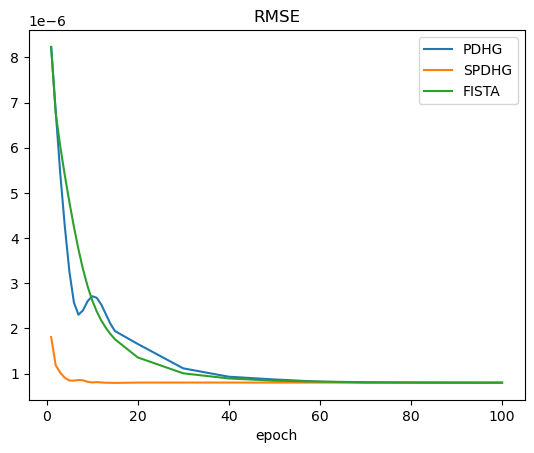

In [3]:
# epochs = [it * 10 for it in range(1,11)]
plt.plot(res_pdhg['iterations'][1:], res_pdhg['rmse'], label='PDHG' )
plt.plot([el / Nms for el in res_spdhg['iterations'][1:]], res_spdhg['rmse'], label='SPDHG' )
plt.plot(res_fista['iterations'][1:], res_fista['rmse'], label='FISTA' )
# plt.plot(epochs_spdhg, res_spdhg_all['rmse'], label='SPDHG' )
plt.legend()
plt.title('RMSE')
plt.xlabel('epoch')
plt.show()

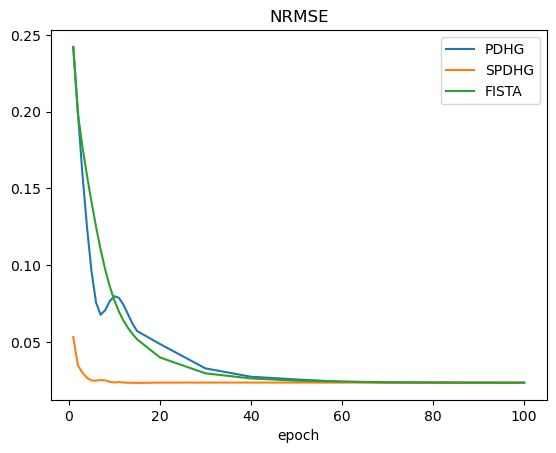

In [4]:
plt.plot(res_pdhg['iterations'][1:], res_pdhg['nrmse'], label='PDHG' )
plt.plot([el / Nms for el in res_spdhg['iterations'][1:]], res_spdhg['nrmse'], label='SPDHG' )
plt.plot(res_fista['iterations'][1:], res_fista['nrmse'], label='FISTA' )
plt.legend()
plt.title('NRMSE')
plt.xlabel('epoch')
plt.show()

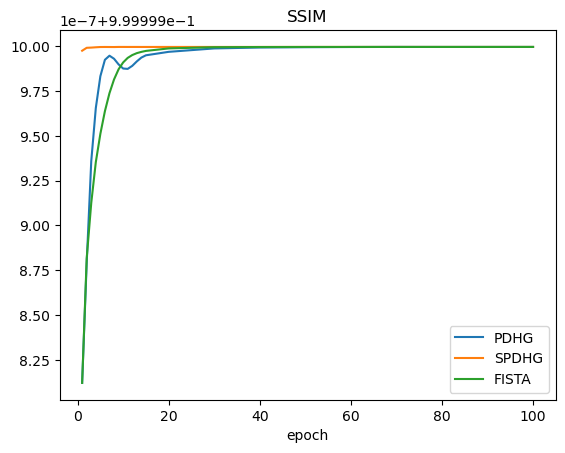

In [5]:
plt.plot(res_pdhg['iterations'][1:], res_pdhg['ssim'], label='PDHG' )
plt.plot([el / Nms for el in res_spdhg['iterations'][1:]], res_spdhg['ssim'], label='SPDHG' )
plt.plot(res_fista['iterations'][1:], res_fista['ssim'], label='FISTA' )
plt.legend()
plt.title('SSIM')
plt.xlabel('epoch')
plt.show()

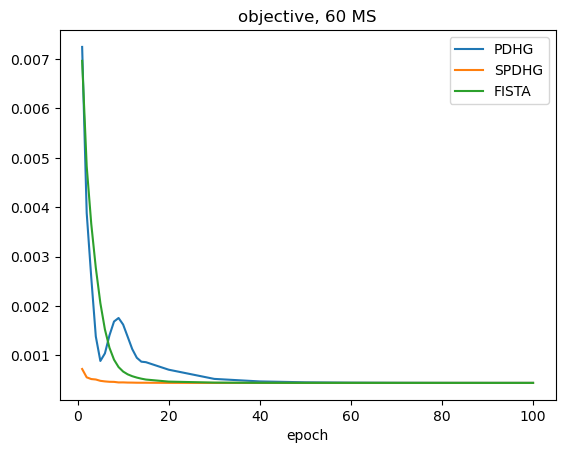

In [6]:

offset = 1
scale = 'linear'
plt.plot(res_pdhg['iterations'][offset:], res_pdhg['objective'][offset:], label='PDHG' )
plt.plot([el / Nms for el in res_spdhg['iterations'][offset:]], res_spdhg['objective'][offset:], label='SPDHG' )
plt.plot(res_fista['iterations'][offset:], res_fista['objective'][offset:], label='FISTA' )
plt.xscale(scale)
plt.title(f'objective, {Nms} MS')
plt.xlabel('epoch')
plt.legend()
plt.show()



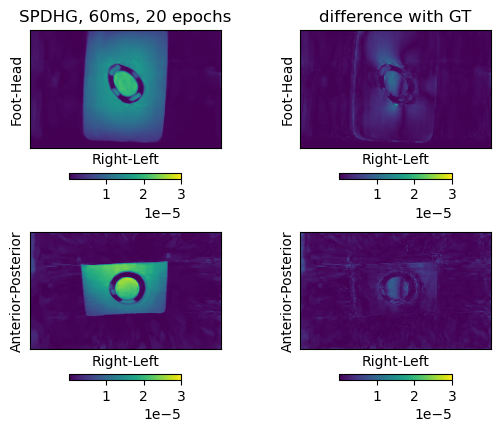

In [7]:
num_epochs = 20
_fname = os.path.join(data_path, 'recons', f'MS_{Nms}','SPDHG_TV_{}ms_it_{:03d}.h5'.format(Nms, Nms * num_epochs) )
im = pMR.ImageData(_fname)
plot_rpe_3d([im.as_array(), im.as_array() - ground_truth_with_TV],
            [59, 64] * 2,
            [f'SPDHG, {Nms}ms, {num_epochs} epochs', 'difference with GT'],
            [3*10**(-5)]*2,
            f'SPDHG, {Nms}ms.png')

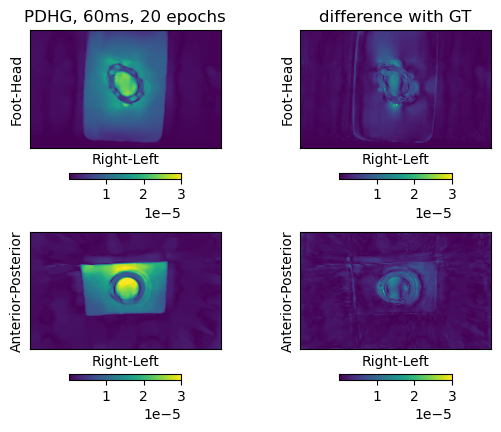

In [8]:
_fname = os.path.join(data_path, 'recons', f'MS_{Nms}','PDHG_TV_{}ms_it_{:03d}.h5'.format(Nms, num_epochs) )
im = pMR.ImageData(_fname)
plot_rpe_3d([im.as_array(), im.as_array() -ground_truth_with_TV],
            [59, 64]*2,
            [f'PDHG, {Nms}ms, {num_epochs} epochs', 'difference with GT'],
            [3*10**(-5)]*2,
            f'PDHG, {Nms}ms.png')

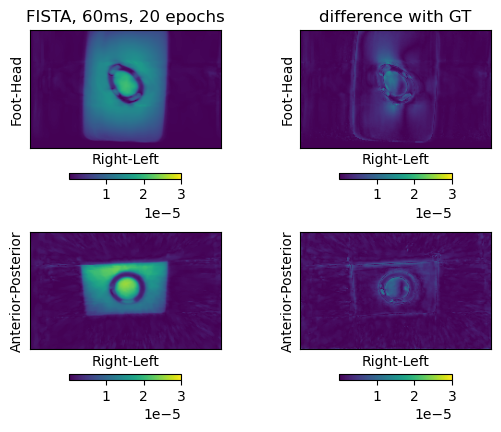

In [9]:
_fname = os.path.join(data_path, 'recons', f'MS_{Nms}','FISTA_TV_{}ms_it_{:03d}.h5'.format(Nms, num_epochs) )
im = pMR.ImageData(_fname)
plot_rpe_3d([im.as_array(), im.as_array() - ground_truth_with_TV],
            [59, 64] * 2,
            [f'FISTA, {Nms}ms, {num_epochs} epochs', 'difference with GT'],
            [3*10**(-5)]*2,
            f'FISTA, {Nms}ms.png')

In [ ]:
plot_rpe_3d([ground_truth_with_TV],
            [59, 64],
            [f'Ground Truth: TV-PDHG, no motion'],
            [3*10**(-5)],
            f'Ground-Truth PDHG, {Nms}ms.png')

In [19]:
# Comparison wrt Nms
num_ms = [6, 30, 60]

results = {}
for algo in ['PDHG', 'SPDHG', 'FISTA']:
    results[algo] = {}

for num in num_ms:
    for algo in ['PDHG', 'SPDHG', 'FISTA']:
        results[algo][str(num)] = read_data(data_path, algo, num, ground_truth_with_TV)
        


14
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-10-10 21:36:14
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-10-11 00:04:31
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-10-11 00:04:31
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-10-11 00:04:31
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-10-11 02:35:49
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-10-11 02:35:49
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-10-11 02:35:49
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-10-11 05:04:01
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-10-11 05:04:01
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-10-11 05:04:01
variable image_0
number of images: 1
image data

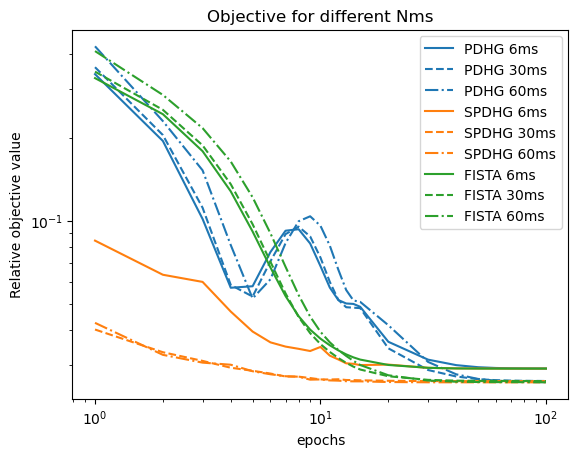

In [28]:
offset = 1
scale = 'log'
linestyle = ['-', '--', '-.']
linecolor = ['C0', 'C1', 'C2']

for i,algo in enumerate(['PDHG', 'SPDHG', 'FISTA']):
    for j,num in enumerate(num_ms):
        epochs = results[algo][str(num)]['iterations']
        if algo == 'SPDHG':
            epochs = [el / num for el in epochs]
        objective = results[algo][str(num)]['objective']
        plt.plot(epochs[offset:], objective[offset:]/objective[0], label=f'{algo} {num}ms' , linestyle=linestyle[j], color=linecolor[i])
plt.xscale(scale)
plt.yscale(scale)
plt.title(f'Objective for different Nms')
plt.xlabel('epochs')
plt.ylabel('Relative objective value')
plt.legend()
plt.show()
